# Generate Segmentation Example

This notebook generates good and bad segmentation examples with cellpose. For educational purposes and better comparison, we generate the segmentation masks with cellpose for the same region of interest using good and suboptimal parameters. 

If your image segmentation yields poor results, we recommend the following guides for troubleshooting: 

- [ ] The cellpose FAQ: https://cellpose.readthedocs.io/en/latest/faq.html
- [ ] The image.sc user forum: https://forum.image.sc/c/image-analysis

Generally, the following approaches might help (with increasing complexity):

- [ ] Adapting the cellpose parameters
- [ ] Finetuning a custom cellpose model 
- [ ] Using an alternative segmentation model like StarDist, InstantSeg, μSAM, etc.


## References

- Stringer, C., Wang, T., Michaelos, M. & Pachitariu, M. Cellpose: a generalist algorithm for cellular segmentation. Nat Methods 18, 100–106 (2021).
- Pachitariu, M., Rariden, M. & Stringer, C. Cellpose-SAM: superhuman generalization for cellular segmentation. 2025.04.28.651001 Preprint at https://doi.org/10.1101/2025.04.28.651001 (2025).
- Schmidt, U., Weigert, M., Broaddus, C. & Myers, G. Cell Detection with Star-convex Polygons. Preprint at https://doi.org/10.48550/arXiv.1806.03535 (2018).
- Goldsborough, T. et al. InstanSeg: an embedding-based instance segmentation algorithm optimized for accurate, efficient and portable cell segmentation. Preprint at https://doi.org/10.48550/arXiv.2408.15954 (2024).
- Archit, A. et al. Segment Anything for Microscopy. Nat Methods 22, 579–591 (2025).

## Generate examples

Run in the described environment (`../README`) on the melanoma `.tiff` example

In [57]:
from pathlib import Path

import harpy
import matplotlib as mpl
import matplotlib.pyplot as plt
import spatialdata as sd
import spatialdata_plot  # noqa
from matplotlib.patches import Patch
from napari_spatialdata import Interactive
from spatialdata_io.readers.generic import image as spatialdata_imread

In [2]:
image_path = Path(
    "../../data/2025_02_19_wholeTissue_melanomaAb_01-Scene-2-ScanRegion1big_c1-3.tiff"
)

In [ ]:
image = spatialdata_imread(
    image_path, data_axes=("x", "y", "c"), coordinate_system="global"
)
sdata = sd.SpatialData(images={"image": image}).query.bounding_box(
    axes=("y", "x"),
    min_coordinate=[40000, 6000],
    max_coordinate=[41000, 7000],
    target_coordinate_system="global",
)

sdata.write("../results/sdata.zarr")

no parent found for <ome_zarr.reader.Label object at 0x3706d9160>: None


no parent found for <ome_zarr.reader.Label object at 0x376b07610>: None
no parent found for <ome_zarr.reader.Label object at 0x376b07ed0>: None


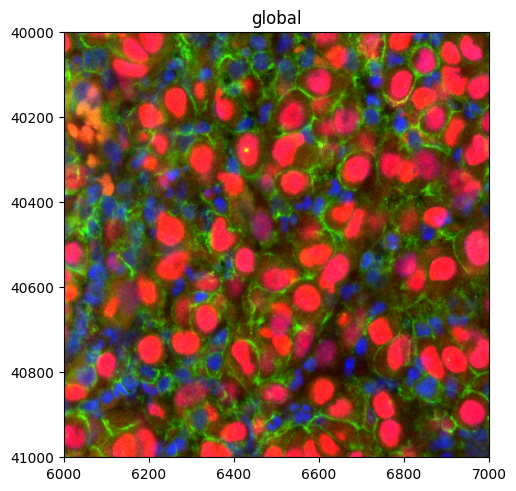

In [4]:
sdata = sd.read_zarr("../results/sdata.zarr")

sdata.pl.render_images().pl.show()

In [ ]:
# Runs ca. 1min on MacOS/M3


def lobotomized_cellpose(image, **kwargs):
    # only segment on cytosol channel
    image = image[..., [1]]
    return harpy.im.cellpose_callable(image, **kwargs)


harpy.im.segment(
    sdata,
    img_layer="image",
    model=lobotomized_cellpose,
    output_labels_layer="segmentation_mask__oversegmentation",
    output_shapes_layer="segmentation_contours__oversegmentation",
    normalize=True,
    min_size=0,
    flow_threshold=10,
    cellprob_threshold=-10,
    overwrite=True,
)

harpy.im.segment(
    sdata,
    img_layer="image",
    model=harpy.im.cellpose_callable,
    output_labels_layer="segmentation_mask__ok",
    output_shapes_layer="segmentation_contours__ok",
    flow_threshold=0.6,
    cellprob_threshold=-4,
    normalize=True,
    overwrite=True,
)

harpy.im.segment(
    sdata,
    img_layer="image",
    model=harpy.im.cellpose_callable,
    output_labels_layer="segmentation_mask__undersegmentation",
    output_shapes_layer="segmentation_contours__undersegmentation",
    flow_threshold=2,
    cellprob_threshold=5,
    overwrite=True,
)

pretrained model /Users/lucas-diedrich/.cellpose/models/cpsam not found, using default model
channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-04-15 17:31:52.715 | INFO     | harpy.image.segmentation._segmentation:_segment:681 - Linking labels across chunks.
2026-04-15 17:31:52.718 | INFO     | harpy.image._manager:add_layer:47 - Writing results to layer 'segmentation_mask__oversegmentation'
no parent found for <ome_zarr.reader.Label object at 0x388fffe00>: None
2026-04-15 17:31:52.931 | INFO     | harpy.shape._manager:_mask_to_polygons_rasterio:339 - Finished vectorizing. Dissolving shapes at the border of the chunks. This can take a couple minutes if input mask contains many chunks.
2026-04-15 17:31:52.947 | INFO     | harpy.shape._manager:_mask_to_polygons_rasterio:345 - Dissolve is done.
pretrained model /Users/lucas-diedrich/.cellpose/models/cpsam not found, using default model
channels deprecated in v4.0.1+. If data 

SpatialData object, with associated Zarr store: /Users/lucas-diedrich/Documents/Projects/other/nature-protocol-dvp/code/dvp-protocol-code/figures/results/sdata.zarr
├── Images
│     └── 'image': DataArray[cyx] (3, 1000, 1000)
├── Labels
│     ├── 'segmentation_mask__ok': DataArray[yx] (1000, 1000)
│     ├── 'segmentation_mask__oversegmentation': DataArray[yx] (1000, 1000)
│     └── 'segmentation_mask__undersegmentation': DataArray[yx] (1000, 1000)
└── Shapes
      ├── 'segmentation_contours__ok': GeoDataFrame shape: (301, 1) (2D shapes)
      ├── 'segmentation_contours__oversegmentation': GeoDataFrame shape: (313, 1) (2D shapes)
      └── 'segmentation_contours__undersegmentation': GeoDataFrame shape: (138, 1) (2D shapes)
with coordinate systems:
    ▸ 'global', with elements:
        image (Images), segmentation_mask__ok (Labels), segmentation_mask__oversegmentation (Labels), segmentation_mask__undersegmentation (Labels), segmentation_contours__ok (Shapes), segmentation_contours__over

In [ ]:
RESOLUTION = 1.725e-01  # micrometers per pixel
scalebar_length = 50  # micrometers

WARNING  render_images: You're blending multiple cmaps. If the plot doesn't look like you expect, it might be      
         because your cmaps go from a given color to 'white', and not to 'transparent'. Therefore, the 'white' of  
         higher layers will overlay the lower layers. Consider using 'palette' instead.                            
WARNING  render_images: You're blending multiple cmaps. If the plot doesn't look like you expect, it might be      
         because your cmaps go from a given color to 'white', and not to 'transparent'. Therefore, the 'white' of  
         higher layers will overlay the lower layers. Consider using 'palette' instead.                            
WARNING  render_images: You're blending multiple cmaps. If the plot doesn't look like you expect, it might be      
         because your cmaps go from a given color to 'white', and not to 'transparent'. Therefore, the 'white' of  
         higher layers will overlay the lower layers. Consider using 'pa

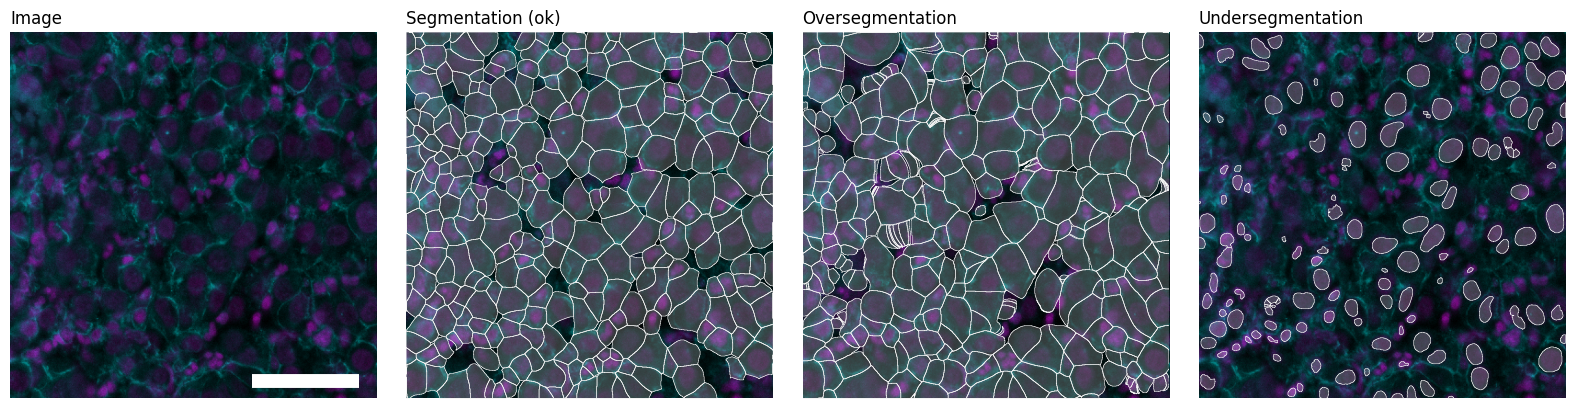

In [56]:
# Runs ca. 2min on MacOS/M3
cyan = mpl.colors.LinearSegmentedColormap.from_list("test", ["#000000", "#00FFFF"])
magenta = mpl.colors.LinearSegmentedColormap.from_list("test", ["#000000", "#FF00FF"])

fig, axs = plt.subplots(1, 4, figsize=(16, 4))


layers = [
    "segmentation_contours__ok",
    "segmentation_contours__oversegmentation",
    "segmentation_contours__undersegmentation",
]

(
    sdata.pl.render_images("image", channel=[1, 2], cmap=[cyan, magenta]).pl.show(
        ax=axs[0], title=""
    )
)

for yi, layer in enumerate(layers):
    (
        sdata.pl.render_images("image", channel=[1, 2], cmap=[cyan, magenta])
        .pl.render_shapes(
            layer, outline_color="#ffffff", outline_width=0.4, fill_alpha=0.25
        )
        .pl.show(ax=axs[yi + 1], title="")
    )

xlim = axs[0].get_xlim()
ylim = axs[0].get_ylim()
offset = 50

axs[0].hlines(
    ylim[0] - offset,
    xlim[1] - offset - scalebar_length * 1 / RESOLUTION,
    xlim[1] - offset,
    color="#ffffff",
    lw=10,
    zorder=1,
)


for ax in axs.ravel():
    ax.set_axis_off()

axs[0].set_title("Image", loc="left")
axs[1].set_title("Segmentation (ok)", loc="left")
axs[2].set_title("Oversegmentation", loc="left")
axs[3].set_title("Undersegmentation", loc="left")

plt.tight_layout()
fig.savefig(
    "../results/segmentation-results.png",
    dpi=600,
    bbox_inches="tight",
    transparent=True,
)

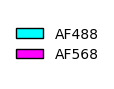

In [66]:
fig, ax = plt.subplots(figsize=(1, 1))

legend_elements = [
    Patch(facecolor="#00FFFF", label="AF488", edgecolor="k"),
    Patch(facecolor="#FF00FF", label="AF568", edgecolor="k"),
]

ax.legend(handles=legend_elements, loc="center", frameon=False)
ax.axis("off")
plt.tight_layout()

fig.savefig("../results/segmentation-results.legend.png", dpi=600, transparent=True)
plt.show()

In [ ]:
run = Interactive(sdata)
run.run()

2026-04-15 17:32:07.764 | WARNING  | napari_spatialdata._viewer:__init__:56 - Due to Shift-L being used as shortcut in napari, it is being deprecated and might not link a new layer to an existing SpatialData object in the viewer. Please use ⌘-L on MacOS or else Ctrl-L.
